In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
titanic_df = pd.read_csv('titanic.csv')
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


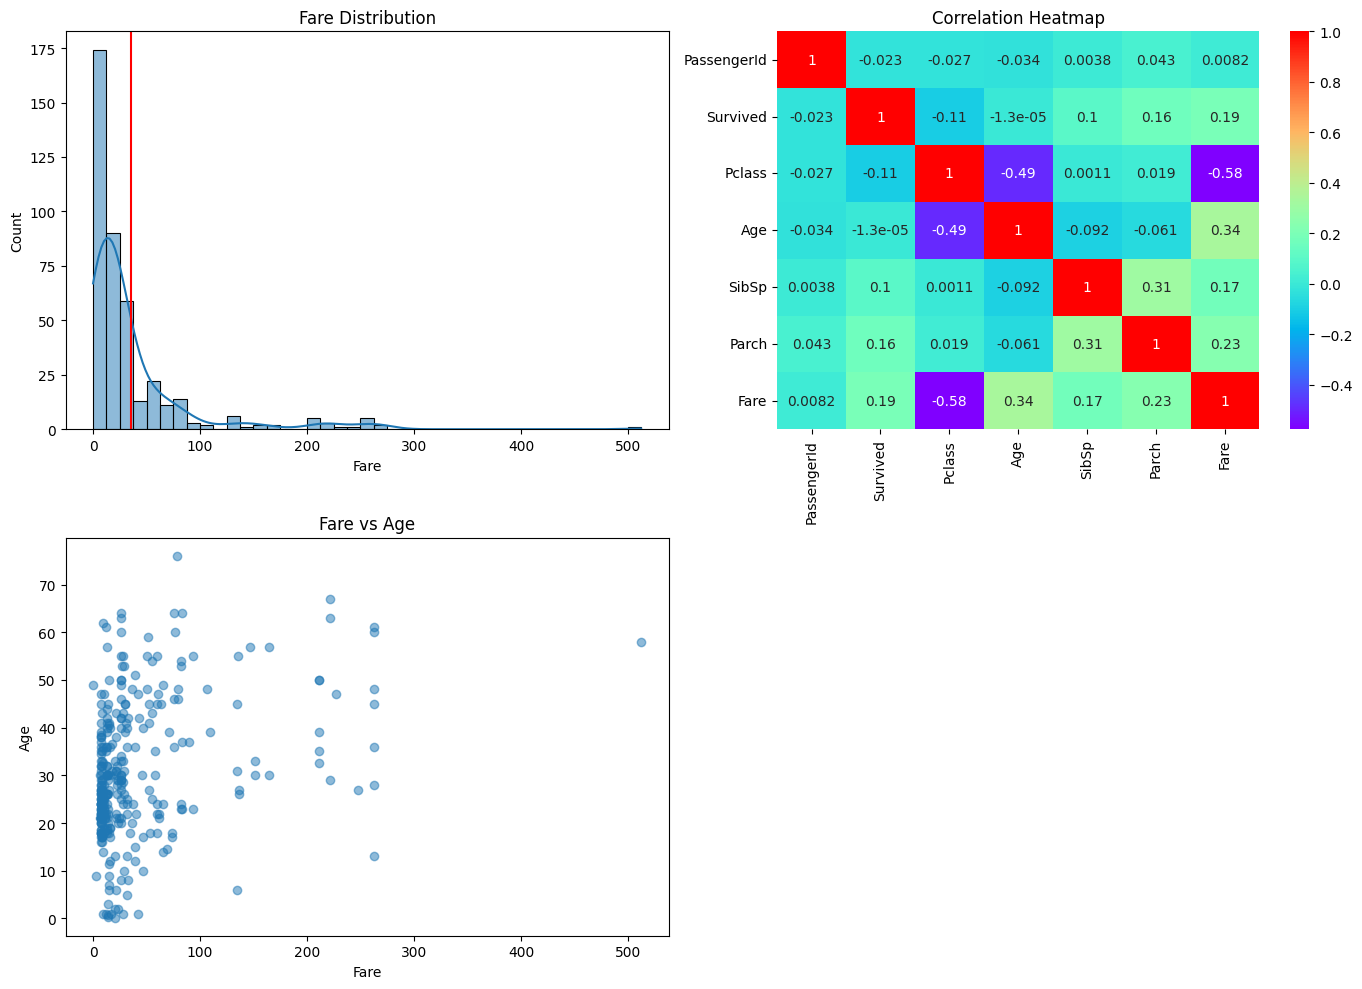

In [14]:
# 1. Define the overall figure size ONCE at the start
plt.figure(figsize=(14, 10))

# 2. First Plot (Top Left)
plt.subplot(2, 2, 1)
# Note: sns.distplot is deprecated, sns.histplot(kde=True) is the modern equivalent
sns.histplot(titanic_df['Fare'], kde=True) 
plt.axvline(titanic_df['Fare'].mean(), color='red', linestyle='-')
plt.title('Fare Distribution')

# 3. Second Plot (Top Right)
plt.subplot(2, 2, 2)
# FIX: Added numeric_only=True to prevent the ValueError
sns.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap='rainbow')
plt.title('Correlation Heatmap')

# 4. Third Plot (Bottom Left)
plt.subplot(2, 2, 3)
plt.scatter(titanic_df['Fare'], titanic_df['Age'], alpha=0.5)
plt.xlabel('Fare')
plt.ylabel('Age')
plt.title('Fare vs Age')

# 5. Prevent overlapping labels and show the grid ONCE at the end
plt.tight_layout()
plt.show()

In [18]:
# Define Y and fill any missing Fare values with the median
Y = titanic_df['Fare']
Y = Y.fillna(Y.median())
# 1. Prepare X
X = titanic_df.drop(['Survived', 'Fare', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median())

# 2. Prepare Y (NEW FIX HERE)
Y = titanic_df['Fare']
Y = Y.fillna(Y.median())

# --- SCALING ---
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# --- TEST TRAIN SPLIT ---
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=10)

# --- LINEAR REGRESSION ---
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()

# --- MODEL FIT ---
lin_model.fit(X_train, Y_train)
print("Intercept:", lin_model.intercept_)
print("Coefficients:", lin_model.coef_)

# --- PREDICTION & EVALUATION ---
y_pred = lin_model.predict(X_test)
print("\nFirst 5 Predictions:", y_pred[:5])

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nMean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Intercept: 76.34215620880943
Coefficients: [  5.2523192  -61.34198504  25.70686589  62.38522906 101.50907903
 -11.04105806 -16.83768981 -21.62227635]

First 5 Predictions: [39.06002622 42.37618372 -3.19104323 99.9195089   5.99398066]

Mean Absolute Error: 26.939132086895825
Mean Squared Error: 1885.5666771320775
Root Mean Squared Error: 43.42311224603872
